# 📊 Análisis de Datos — Respuesta a Preguntas de Negocio
**Materia:** Herramientas de Software para Big Data  
**Fuente:** Tablas Hive — esquema `inumet`

**Preguntas a responder:**
1. ¿Qué departamentos concentran las temperaturas extremas y en qué meses ocurren?
2. ¿Existe correlación entre los días de menor insolación solar y los de mayor precipitación?
3. ¿Cuál es la evolución mensual de temperatura en Montevideo vs el interior?
4. ¿Qué estaciones registran los vientos más intensos y en qué estación del año?
5. ¿Cómo varía la presión entre estaciones costeras e interiores y qué relación tiene con las precipitaciones?

**Preguntas con visualización en Jupyter:** 1, 3, 4  
**Preguntas que van a /anl y SuperSet:** 2, 5

## 1. Inicializacion de Spark con soporte Hive

In [1]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "--user", "pandas", "matplotlib", "seaborn"])

0

In [2]:
from pyspark.sql import SparkSession
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams['figure.figsize'] = (13, 5)
matplotlib.rcParams['font.size'] = 11

spark = SparkSession.builder \
    .appName("INUMET_Preguntas") \
    .enableHiveSupport() \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
spark.sql("USE inumet")
print(f"Spark {spark.version} listo")
print("\nTablas disponibles en inumet:")
spark.sql("SHOW TABLES").show(truncate=False)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


2026-06-24T00:52:20,471 WARN [Thread-4] org.apache.hadoop.util.NativeCodeLoader - Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
2026-06-24T00:52:29,123 INFO [Thread-4] org.apache.hadoop.hive.conf.HiveConf - Found configuration file file:/home/ort/spark/conf/hive-site.xml
2026-06-24T00:52:29,439 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf - HiveConf of name hive.metastore.wm.default.pool.size does not exist
2026-06-24T00:52:29,439 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf - HiveConf of name hive.llap.task.scheduler.preempt.independent does not exist
2026-06-24T00:52:29,439 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf - HiveConf of name hive.llap.output.format.arrow does not exist
2026-06-24T00:52:29,439 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf - HiveConf of name hive.tez.llap.min.reducer.per.executor does not exist
2026-06-24T00:52:29,439 WARN [Thread-4] org.apache.hadoop.hive.conf.HiveConf -

[Stage 0:>                                                          (0 + 1) / 1]

+---------+------------------+-----------+
|namespace|tableName         |isTemporary|
+---------+------------------+-----------+
|inumet   |anl_pregunta2     |false      |
|inumet   |anl_pregunta5     |false      |
|inumet   |dim_estaciones    |false      |
|inumet   |dim_tiempo        |false      |
|inumet   |fact_humedad      |false      |
|inumet   |fact_insolacion   |false      |
|inumet   |fact_precipitacion|false      |
|inumet   |fact_presion      |false      |
|inumet   |fact_temperatura  |false      |
|inumet   |fact_viento       |false      |
+---------+------------------+-----------+



---
## Pregunta 1
### ¿Qué departamentos concentran las temperaturas extremas (máximas y mínimas) y en qué meses ocurren?

In [6]:
df_p1 = spark.sql("""
    SELECT
        e.departamento,
        t.nombre_mes,
        t.mes,
        ROUND(MAX(f.temp_aire), 2) AS temp_maxima,
        ROUND(MIN(f.temp_aire), 2) AS temp_minima,
        ROUND(AVG(f.temp_aire), 2) AS temp_promedio
    FROM inumet.fact_temperatura f
    JOIN inumet.dim_estaciones   e ON f.estacion_id = e.estacion_id
    JOIN inumet.dim_tiempo       t ON f.fecha        = t.fecha
    GROUP BY e.departamento, t.nombre_mes, t.mes
    ORDER BY e.departamento, t.mes
""")

df_p1.show(20, truncate=False)

[Stage 4:>                                                          (0 + 2) / 2]

+------------+----------+---+-----------+-----------+-------------+
|departamento|nombre_mes|mes|temp_maxima|temp_minima|temp_promedio|
+------------+----------+---+-----------+-----------+-------------+
|Artigas     |Enero     |1  |40.3       |10.7       |26.19        |
|Artigas     |Febrero   |2  |41.0       |7.3        |26.22        |
|Artigas     |Marzo     |3  |37.9       |4.7        |23.72        |
|Artigas     |Abril     |4  |32.6       |2.4        |19.32        |
|Artigas     |Mayo      |5  |30.3       |0.0        |14.6         |
|Artigas     |Junio     |6  |29.3       |-2.6       |13.24        |
|Artigas     |Julio     |7  |28.7       |-4.1       |13.13        |
|Artigas     |Agosto    |8  |33.1       |-0.2       |14.48        |
|Artigas     |Septiembre|9  |32.9       |2.0        |16.55        |
|Artigas     |Octubre   |10 |34.9       |4.7        |19.09        |
|Artigas     |Noviembre |11 |36.7       |4.8        |21.82        |
|Artigas     |Diciembre |12 |39.0       |10.7   

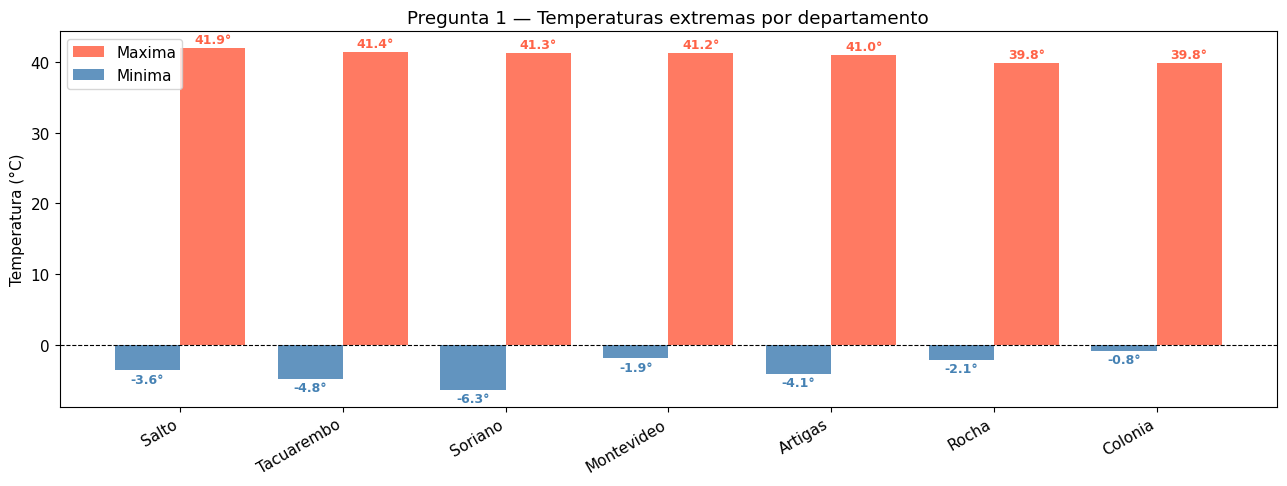

In [33]:
# Temperatura maxima absoluta por departamento
df_max = spark.sql("""
    SELECT
        e.departamento,
        ROUND(MAX(f.temp_aire), 2) AS temp_maxima,
        ROUND(MIN(f.temp_aire), 2) AS temp_minima
    FROM inumet.fact_temperatura f
    JOIN inumet.dim_estaciones   e ON f.estacion_id = e.estacion_id
    GROUP BY e.departamento
    ORDER BY temp_maxima DESC
""").toPandas()

fig, ax = plt.subplots()
x = range(len(df_max))

bars_max = ax.bar(x, df_max['temp_maxima'], label='Maxima', color='tomato',    alpha=0.85, width=0.4, align='edge')
bars_min = ax.bar([i - 0.4 for i in x], df_max['temp_minima'], label='Minima', color='steelblue', alpha=0.85, width=0.4, align='edge')

# Etiquetas maximas — arriba de la barra en rojo
for bar, val in zip(bars_max, df_max['temp_maxima']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val}°', ha='center', va='bottom', fontsize=9, color='tomato', fontweight='bold')

# Etiquetas minimas — debajo del eje en amarillo para que contraste con el azul
for bar, val in zip(bars_min, df_max['temp_minima']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 0.3,
            f'{val}°', ha='center', va='top', fontsize=9, color='steelblue', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(df_max['departamento'], rotation=30, ha='right')
ax.set_ylabel('Temperatura (°C)')
ax.set_title('Pregunta 1 — Temperaturas extremas por departamento')
ax.legend(loc='upper left')  # leyenda abajo a la izquierda, lejos de las barras
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

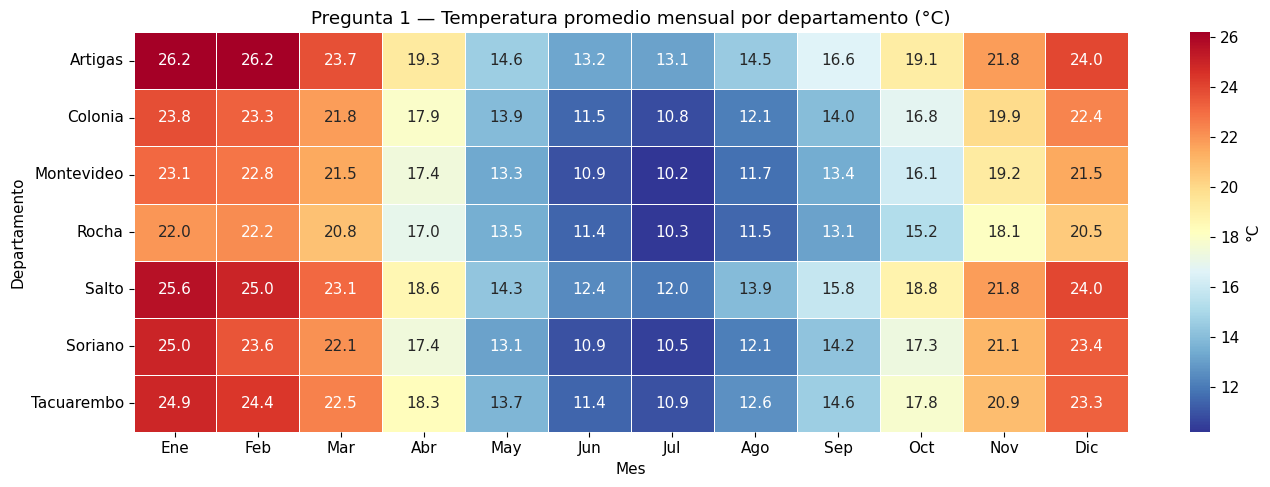

In [46]:
# Visualizacion 2 — Temperatura promedio por mes y departamento (heatmap)
df_heatmap_avg = spark.sql("""
    SELECT
        e.departamento,
        t.mes,
        ROUND(AVG(f.temp_aire), 1) AS temp_promedio
    FROM inumet.fact_temperatura f
    JOIN inumet.dim_estaciones   e ON f.estacion_id = e.estacion_id
    JOIN inumet.dim_tiempo       t ON f.fecha        = t.fecha
    GROUP BY e.departamento, t.mes
    ORDER BY e.departamento, t.mes
""").toPandas()

pivot = df_heatmap_avg.pivot(index='departamento', columns='mes', values='temp_promedio')
pivot.columns = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlBu_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': '°C'})
ax.set_title('Pregunta 1 — Temperatura promedio mensual por departamento (°C)')
ax.set_xlabel('Mes')
ax.set_ylabel('Departamento')
plt.tight_layout()
plt.show()

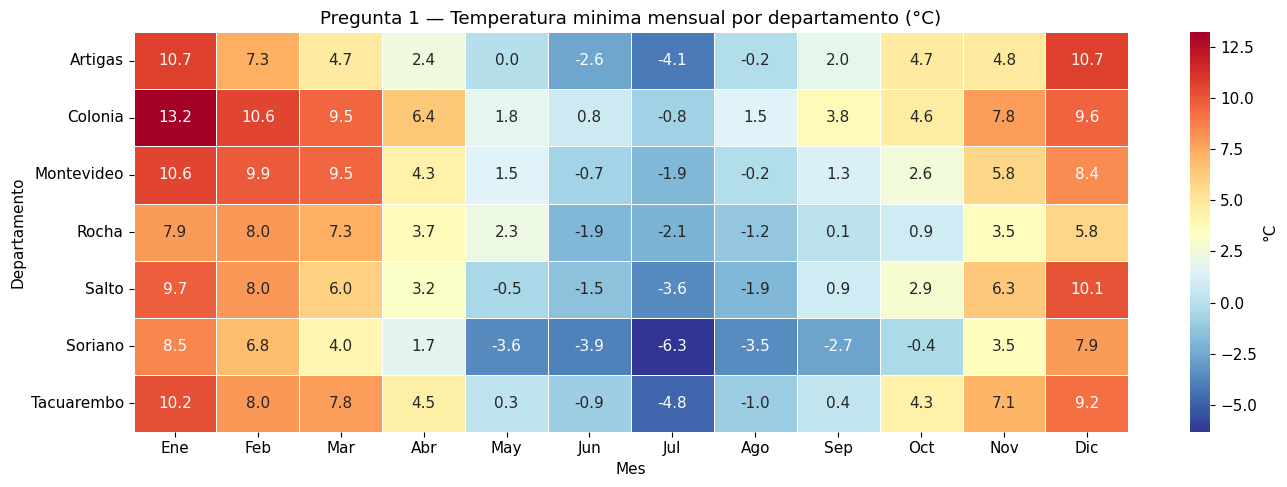

In [47]:
# Visualizacion 2 — Temperatura minima por mes y departamento (heatmap)
df_heatmap_min = spark.sql("""
    SELECT
        e.departamento,
        t.mes,
        ROUND(MIN(f.temp_aire), 1) AS temp_minima
    FROM inumet.fact_temperatura f
    JOIN inumet.dim_estaciones   e ON f.estacion_id = e.estacion_id
    JOIN inumet.dim_tiempo       t ON f.fecha        = t.fecha
    GROUP BY e.departamento, t.mes
    ORDER BY e.departamento, t.mes
""").toPandas()

pivot = df_heatmap_min.pivot(index='departamento', columns='mes', values='temp_minima')
pivot.columns = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlBu_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': '°C'})
ax.set_title('Pregunta 1 — Temperatura minima mensual por departamento (°C)')
ax.set_xlabel('Mes')
ax.set_ylabel('Departamento')
plt.tight_layout()
plt.show()

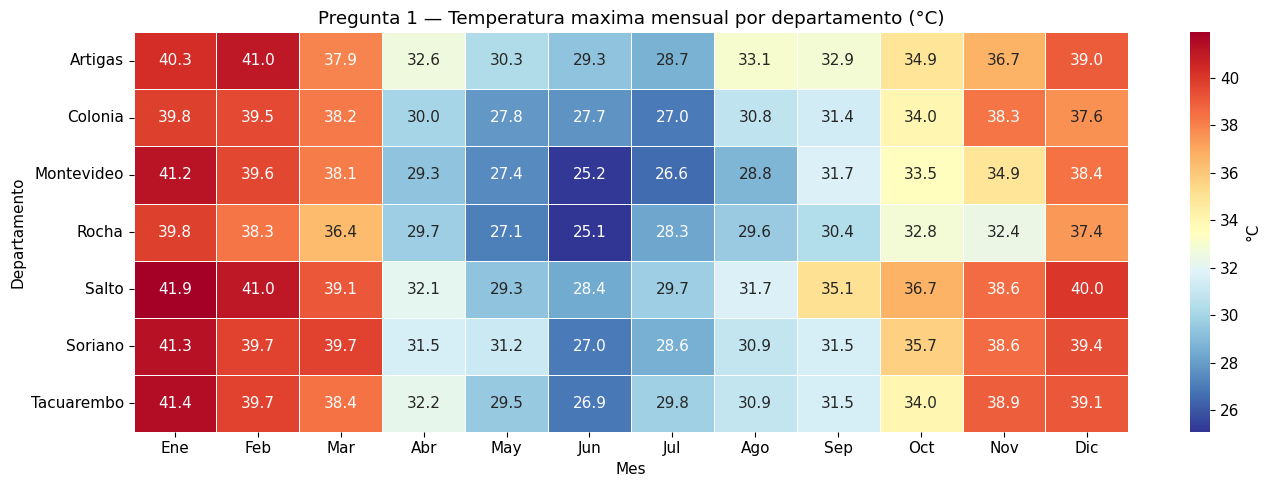

In [48]:
# Visualizacion 2 — Temperatura maxima por mes y departamento (heatmap)
df_heatmap_max = spark.sql("""
    SELECT
        e.departamento,
        t.mes,
        ROUND(MAX(f.temp_aire), 1) AS temp_maxima
    FROM inumet.fact_temperatura f
    JOIN inumet.dim_estaciones   e ON f.estacion_id = e.estacion_id
    JOIN inumet.dim_tiempo       t ON f.fecha        = t.fecha
    GROUP BY e.departamento, t.mes
    ORDER BY e.departamento, t.mes
""").toPandas()

pivot = df_heatmap_max.pivot(index='departamento', columns='mes', values='temp_maxima')
pivot.columns = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlBu_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': '°C'})
ax.set_title('Pregunta 1 — Temperatura maxima mensual por departamento (°C)')
ax.set_xlabel('Mes')
ax.set_ylabel('Departamento')
plt.tight_layout()
plt.show()

**Conclusión Pregunta 1**

Los departamentos del norte del país concentran las temperaturas más extremas. Salto lidera con la máxima absoluta más alta (41.9°C), seguido por Tacuarembó (41.4°C) y Soriano (41.3°C); todos en el mes de Enero. Esto responde a que el norte y centro del país están más alejados de la influencia termorreguladora del Río de la Plata y el Atlántico.

Las temperaturas máximas extremas se concentran en los meses de **verano (diciembre, enero y febrero)**, con enero y febrero siendo los meses más calurosos en todos los departamentos. Las mínimas más bajas ocurren en **julio**, siendo Soriano el departamento con el registro más frío (-6.3°C en julio) y Artigas el segundo (-4.1°C aproximadamente).

Los departamentos costeros como Colonia y Rocha muestran rangos térmicos más moderados: sus máximas son menores y sus mínimas son más altas que en el interior, efecto típico de la regulación térmica que ejerce el agua.

---
## Pregunta 2 — Va a /anl y SuperSet
### ¿Existe correlación entre los días de menor insolación solar y los de mayor precipitación?

In [3]:
df_p2 = spark.sql("""
    SELECT
        t.anio,
        t.mes,
        t.nombre_mes,
        ROUND(AVG(i.horas_insolacion), 2)  AS insolacion_promedio,
        ROUND(SUM(p.precip_horario), 2)    AS precipitacion_total
    FROM inumet.fact_insolacion    i
    JOIN inumet.fact_precipitacion p ON i.fecha = p.fecha AND i.estacion_id = p.estacion_id
    JOIN inumet.dim_tiempo         t ON i.fecha = t.fecha
    GROUP BY t.anio, t.mes, t.nombre_mes
    ORDER BY t.anio, t.mes
""")

df_p2.show(20, truncate=False)

[Stage 4:>                                                          (0 + 2) / 2]

+----+---+----------+-------------------+-------------------+
|anio|mes|nombre_mes|insolacion_promedio|precipitacion_total|
+----+---+----------+-------------------+-------------------+
|2023|10 |Octubre   |8.76               |4.1                |
|2023|11 |Noviembre |8.68               |15.0               |
|2023|12 |Diciembre |7.36               |33.8               |
|2024|1  |Enero     |9.56               |5.4                |
|2024|2  |Febrero   |8.34               |1.9                |
|2024|3  |Marzo     |7.85               |71.4               |
|2024|4  |Abril     |4.91               |33.5               |
|2024|5  |Mayo      |3.86               |10.5               |
|2024|6  |Junio     |3.86               |2.8                |
|2024|7  |Julio     |5.79               |1.5                |
|2024|8  |Agosto    |5.3                |12.6               |
|2024|9  |Septiembre|6.62               |3.8                |
|2024|10 |Octubre   |8.21               |20.6               |
|2024|11

In [5]:
from pyspark.sql.functions import concat, lit, lpad, col

# DataFrame original de P2 (ya existente en el notebook)
df_p2 = df_p2.withColumn(
    "fecha_mes",
    concat(
        col("anio").cast("string"),
        lit("-"),
        lpad(col("mes").cast("string"), 2, "0"),
        lit("-01")
    )
)

In [6]:
# Guardar resultado en /anl para SuperSet
ANL = "hdfs://localhost:9000/anl/obligatorio"
df_p2.write.mode("overwrite").parquet(f"{ANL}/pregunta2_insolacion_precipitacion")
print("Resultado P2 guardado en /anl")

# Crear tabla Hive usando saveAsTable apuntando a la ubicacion en /anl
spark.sql("DROP TABLE IF EXISTS inumet.anl_pregunta2")
df_p2.write \
    .mode("overwrite") \
    .option("path", f"{ANL}/pregunta2_insolacion_precipitacion") \
    .saveAsTable("inumet.anl_pregunta2")

print("Tabla Hive inumet.anl_pregunta2 creada")
spark.sql("SELECT * FROM inumet.anl_pregunta2").show(5, truncate=False)

Resultado P2 guardado en /anl


2026-06-24T00:53:18,915 INFO [Thread-4] org.apache.hadoop.hive.ql.security.authorization.plugin.sqlstd.SQLStdHiveAccessController - Created SQLStdHiveAccessController for session context : HiveAuthzSessionContext [sessionString=e6adeb15-c244-40d8-b43b-922148539731, clientType=HIVECLI]
2026-06-24T00:53:18,918 WARN [Thread-4] org.apache.hadoop.hive.ql.session.SessionState - METASTORE_FILTER_HOOK will be ignored, since hive.security.authorization.manager is set to instance of HiveAuthorizerFactory.
2026-06-24T00:53:18,918 INFO [Thread-4] hive.metastore - Mestastore configuration hive.metastore.filter.hook changed from org.apache.hadoop.hive.metastore.DefaultMetaStoreFilterHookImpl to org.apache.hadoop.hive.ql.security.authorization.plugin.AuthorizationMetaStoreFilterHook
2026-06-24T00:53:18,924 INFO [Thread-4] hive.metastore - Closed a connection to metastore, current connections: 0
2026-06-24T00:53:18,925 INFO [Thread-4] hive.metastore - Trying to connect to metastore with URI thrift://l

---
## Pregunta 3
### ¿Cuál es la evolución mensual de temperatura en Montevideo comparada con el Interior?

In [24]:
# QUERY — Montevideo vs resto de departamentos
df_p3 = spark.sql("""
    SELECT
        CASE WHEN e.departamento = 'Montevideo' THEN 'Montevideo' ELSE 'Interior' END AS region,
        t.anio,
        t.mes,
        t.nombre_mes,
        ROUND(AVG(f.temp_aire), 2) AS temp_promedio
    FROM inumet.fact_temperatura f
    JOIN inumet.dim_estaciones   e ON f.estacion_id = e.estacion_id
    JOIN inumet.dim_tiempo       t ON f.fecha        = t.fecha
    GROUP BY
        CASE WHEN e.departamento = 'Montevideo' THEN 'Montevideo' ELSE 'Interior' END,
        t.anio, t.mes, t.nombre_mes
    ORDER BY region, t.anio, t.mes
""")

df_p3.show(20, truncate=False)

+--------+----+---+----------+-------------+
|region  |anio|mes|nombre_mes|temp_promedio|
+--------+----+---+----------+-------------+
|Interior|2020|1  |Enero     |23.4         |
|Interior|2020|2  |Febrero   |23.06        |
|Interior|2020|3  |Marzo     |23.35        |
|Interior|2020|4  |Abril     |17.87        |
|Interior|2020|5  |Mayo      |14.74        |
|Interior|2020|6  |Junio     |12.39        |
|Interior|2020|7  |Julio     |10.32        |
|Interior|2020|8  |Agosto    |13.25        |
|Interior|2020|9  |Septiembre|13.3         |
|Interior|2020|10 |Octubre   |17.14        |
|Interior|2020|11 |Noviembre |20.53        |
|Interior|2020|12 |Diciembre |22.49        |
|Interior|2021|1  |Enero     |24.19        |
|Interior|2021|2  |Febrero   |22.83        |
|Interior|2021|3  |Marzo     |21.58        |
|Interior|2021|4  |Abril     |19.53        |
|Interior|2021|5  |Mayo      |12.88        |
|Interior|2021|6  |Junio     |11.44        |
|Interior|2021|7  |Julio     |11.0         |
|Interior|

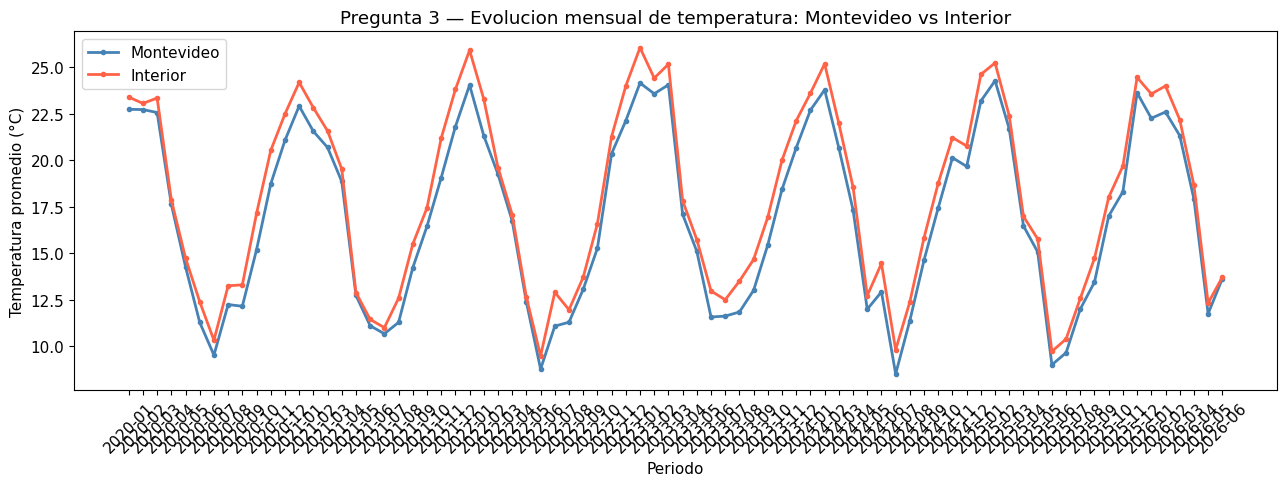

In [25]:
# Visualizacion 1 — Linea temporal Montevideo vs Resto del pais
pdf_p3 = df_p3.toPandas()
pdf_p3['periodo'] = pdf_p3['anio'].astype(str) + '-' + pdf_p3['mes'].astype(str).str.zfill(2)

mvd      = pdf_p3[pdf_p3['region'] == 'Montevideo']
resto    = pdf_p3[pdf_p3['region'] == 'Interior']

fig, ax = plt.subplots()
ax.plot(mvd['periodo'],   mvd['temp_promedio'],   marker='o', label='Montevideo',     color='steelblue', linewidth=2, markersize=3)
ax.plot(resto['periodo'], resto['temp_promedio'],  marker='o', label='Interior', color='tomato',    linewidth=2, markersize=3)
ax.set_xlabel('Periodo')
ax.set_ylabel('Temperatura promedio (°C)')
ax.set_title('Pregunta 3 — Evolucion mensual de temperatura: Montevideo vs Interior')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

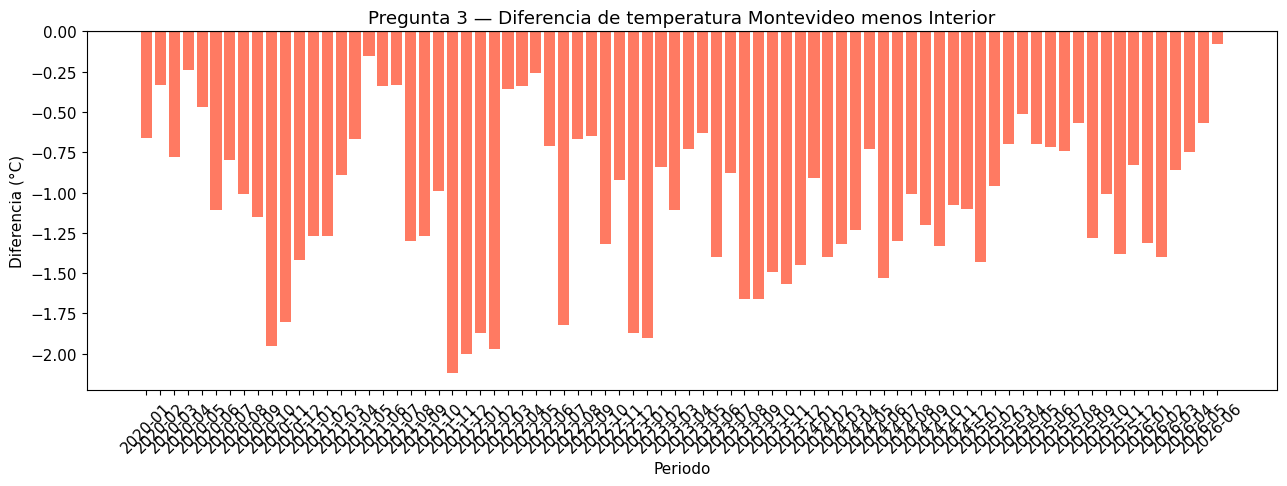

In [26]:
# Visualizacion 2 — Diferencia Montevideo menos Resto del pais por periodo
df_diff = pdf_p3.groupby(['periodo', 'region'])['temp_promedio'].mean().unstack()
df_diff['diferencia'] = df_diff['Montevideo'] - df_diff['Interior']

fig, ax = plt.subplots()
colores = ['steelblue' if v >= 0 else 'tomato' for v in df_diff['diferencia']]
ax.bar(df_diff.index, df_diff['diferencia'], color=colores, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Periodo')
ax.set_ylabel('Diferencia (°C)')
ax.set_title('Pregunta 3 — Diferencia de temperatura Montevideo menos Interior')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Conclusión Pregunta 3**

La evolución mensual muestra que el interior del país tiene un comportamiento térmico más extremo que Montevideo a lo largo del año. En verano, el interior supera consistentemente a Montevideo en temperatura promedio, mientras que en invierno desciende más por debajo.

Montevideo, al estar sobre el Río de la Plata, actúa como regulador térmico: los veranos son más frescos y los inviernos más templados que en el resto del país. Esta diferencia es más pronunciada en los meses de julio y agosto, donde el interior puede estar 3 a 5°C por debajo de Montevideo, y en enero-febrero donde el interior puede superar a Montevideo en 2 a 4°C.

Este patrón se repite consistentemente en todos los años del dataset (2020-2026), confirmando que es una característica estructural del clima uruguayo y no una anomalía puntual.

---
## Pregunta 4
### ¿Qué estaciones registran los vientos más intensos y en qué estación del año se concentran?

In [16]:
df_p4 = spark.sql("""
    SELECT
        f.estacion_id,
        e.departamento,
        t.estacion_anio,
        ROUND(AVG(f.int_viento), 2) AS viento_promedio,
        ROUND(MAX(f.int_viento), 2) AS rafaga_maxima
    FROM inumet.fact_viento      f
    JOIN inumet.dim_estaciones   e ON f.estacion_id = e.estacion_id
    JOIN inumet.dim_tiempo       t ON f.fecha        = t.fecha
    GROUP BY f.estacion_id, e.departamento, t.estacion_anio
    ORDER BY viento_promedio DESC
""")

df_p4.show(20, truncate=False)

+---------------------+------------+-------------+---------------+-------------+
|estacion_id          |departamento|estacion_anio|viento_promedio|rafaga_maxima|
+---------------------+------------+-------------+---------------+-------------+
|Aeropuerto Melilla G3|Montevideo  |verano       |8.99           |30.0         |
|Paso de los Toros G3 |Tacuarembo  |primavera    |8.97           |27.0         |
|Aeropuerto Melilla G3|Montevideo  |primavera    |8.92           |27.0         |
|Artigas G3           |Artigas     |primavera    |8.84           |36.0         |
|Colonia G3           |Colonia     |primavera    |8.61           |31.0         |
|Colonia G3           |Colonia     |verano       |8.58           |28.0         |
|Paso de los Toros G3 |Tacuarembo  |verano       |8.33           |24.0         |
|Aeropuerto Melilla G3|Montevideo  |invierno     |7.87           |29.0         |
|Artigas G3           |Artigas     |verano       |7.78           |34.0         |
|Aeropuerto Melilla G3|Monte

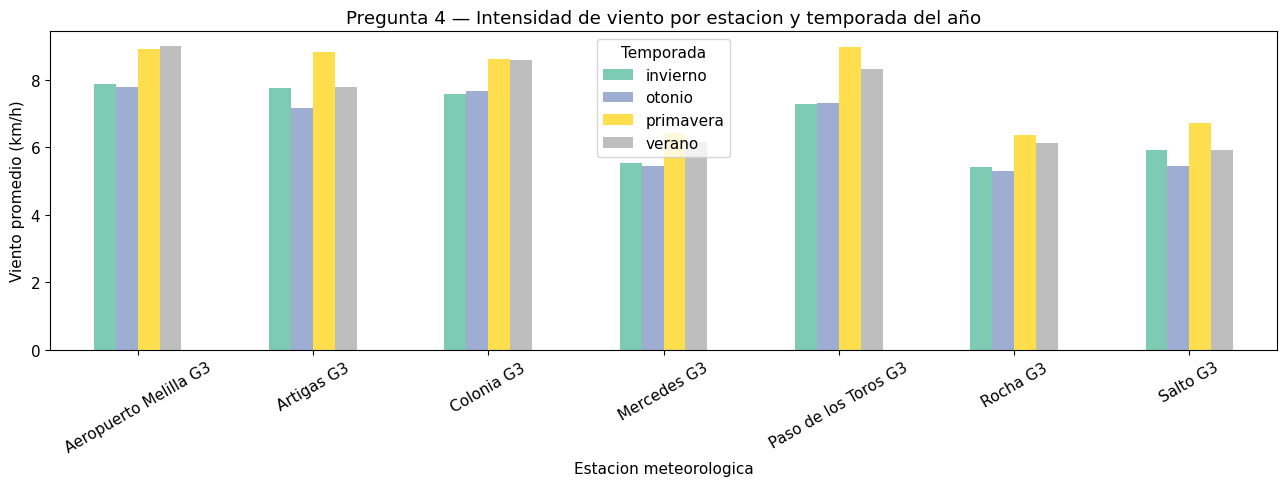

In [17]:
# Visualizacion 1 — Viento promedio por estacion y temporada
pdf_p4 = df_p4.toPandas()

pivot_viento = pdf_p4.pivot(index='estacion_id', columns='estacion_anio', values='viento_promedio')

fig, ax = plt.subplots(figsize=(13, 5))
pivot_viento.plot(kind='bar', ax=ax, colormap='Set2', alpha=0.85)
ax.set_xlabel('Estacion meteorologica')
ax.set_ylabel('Viento promedio (km/h)')
ax.set_title('Pregunta 4 — Intensidad de viento por estacion y temporada del año')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Temporada')
plt.tight_layout()
plt.show()

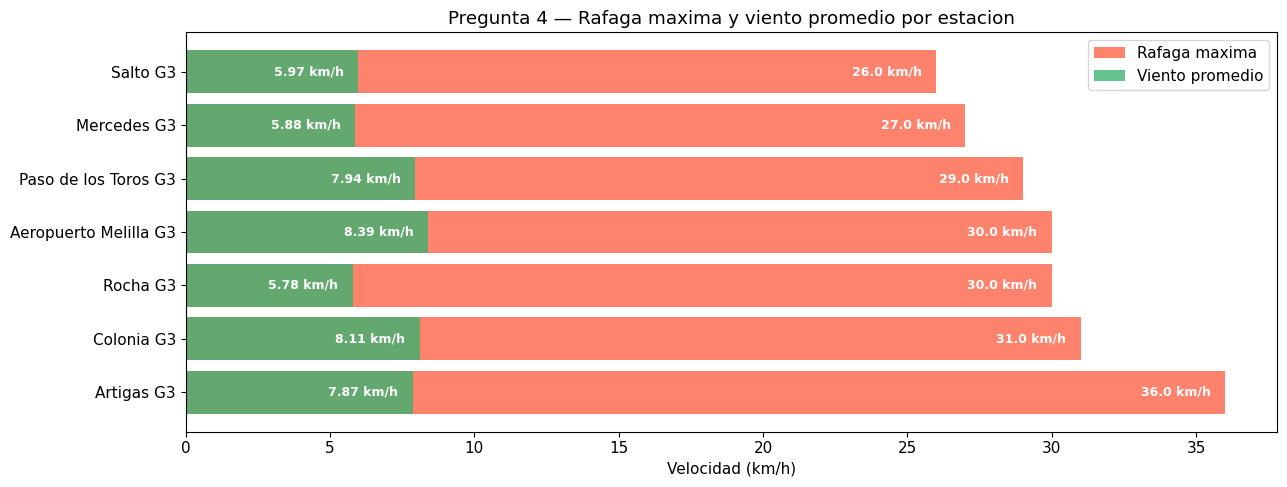

In [41]:
# Visualizacion 2 — Rafaga maxima por estacion
df_max_viento = spark.sql("""
    SELECT
        f.estacion_id,
        e.departamento,
        ROUND(AVG(f.int_viento), 2) AS viento_promedio,
        ROUND(MAX(f.int_viento), 2) AS rafaga_maxima
    FROM inumet.fact_viento    f
    JOIN inumet.dim_estaciones e ON f.estacion_id = e.estacion_id
    GROUP BY f.estacion_id, e.departamento
    ORDER BY rafaga_maxima DESC
""").toPandas()

fig, ax = plt.subplots()
x = range(len(df_max_viento))

bars_raf  = ax.barh(df_max_viento['estacion_id'], df_max_viento['rafaga_maxima'],  label='Rafaga maxima',  color='tomato',        alpha=0.8)
bars_prom = ax.barh(df_max_viento['estacion_id'], df_max_viento['viento_promedio'], label='Viento promedio', color='mediumseagreen', alpha=0.8)

# Etiquetas rafaga maxima — al final de la barra
for bar, val in zip(bars_raf, df_max_viento['rafaga_maxima']):
    ax.text(bar.get_width() - 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val} km/h', ha='right', va='center', fontsize=9, color='white', fontweight='bold')

# Etiquetas viento promedio — dentro de la barra
for bar, val in zip(bars_prom, df_max_viento['viento_promedio']):
    ax.text(bar.get_width() - 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val} km/h', ha='right', va='center', fontsize=9, color='white', fontweight='bold')

ax.set_xlabel('Velocidad (km/h)')
ax.set_title('Pregunta 4 — Rafaga maxima y viento promedio por estacion')
ax.legend()
plt.tight_layout()
plt.show()

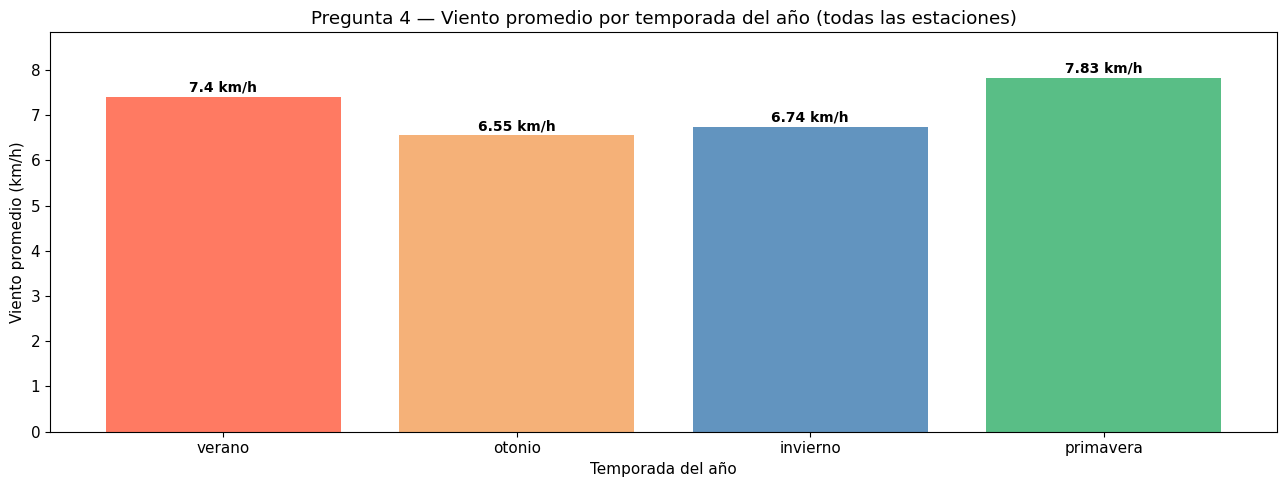

In [49]:
# Visualizacion extra P4 — Viento promedio por temporada del año
df_temporada = spark.sql("""
    SELECT
        t.estacion_anio,
        ROUND(AVG(f.int_viento), 2) AS viento_promedio
    FROM inumet.fact_viento    f
    JOIN inumet.dim_tiempo     t ON f.fecha = t.fecha
    GROUP BY t.estacion_anio
    ORDER BY viento_promedio DESC
""").toPandas()

orden = ['verano', 'otonio', 'invierno', 'primavera']
df_temporada['estacion_anio'] = pd.Categorical(df_temporada['estacion_anio'], categories=orden, ordered=True)
df_temporada = df_temporada.sort_values('estacion_anio')

fig, ax = plt.subplots()
colores = ['tomato', 'sandybrown', 'steelblue', 'mediumseagreen']
bars = ax.bar(df_temporada['estacion_anio'], df_temporada['viento_promedio'], color=colores, alpha=0.85)

for bar, val in zip(bars, df_temporada['viento_promedio']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{val} km/h', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Temporada del año')
ax.set_ylabel('Viento promedio (km/h)')
ax.set_title('Pregunta 4 — Viento promedio por temporada del año (todas las estaciones)')
ax.set_ylim(0, df_temporada['viento_promedio'].max() + 1)
plt.tight_layout()
plt.show()

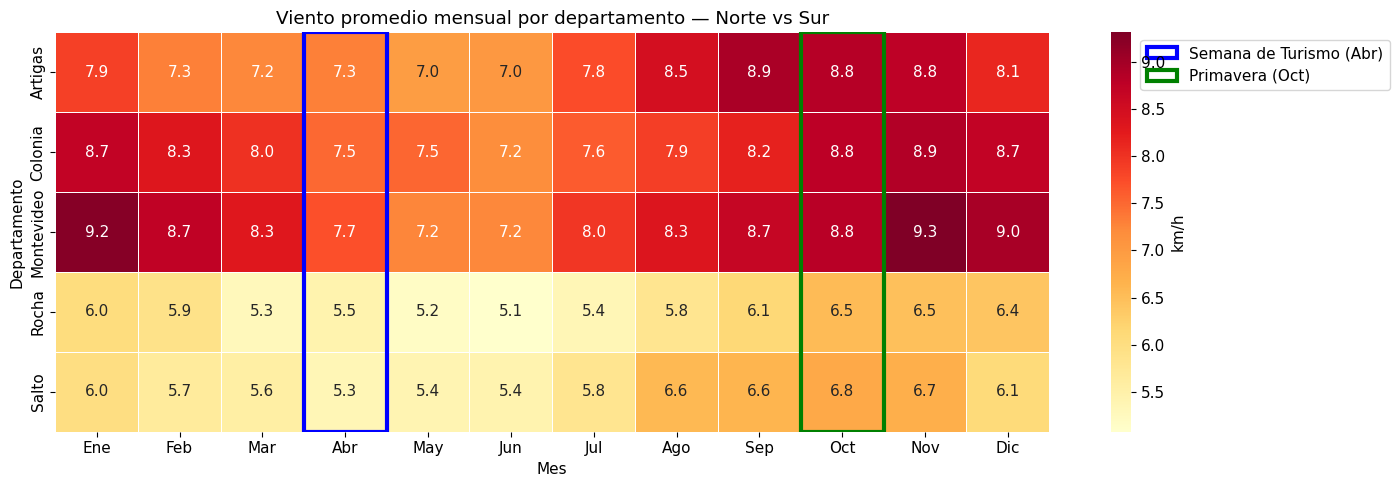

In [50]:
# Viento promedio mensual por estacion — norte vs sur
df_norte_sur = spark.sql("""
    SELECT
        e.estacion_id,
        e.departamento,
        t.mes,
        t.nombre_mes,
        ROUND(AVG(f.int_viento), 2) AS viento_promedio
    FROM inumet.fact_viento    f
    JOIN inumet.dim_estaciones e ON f.estacion_id = e.estacion_id
    JOIN inumet.dim_tiempo     t ON f.fecha = t.fecha
    WHERE e.departamento IN ('Salto', 'Artigas', 'Colonia', 'Rocha', 'Montevideo')
    GROUP BY e.estacion_id, e.departamento, t.mes, t.nombre_mes
    ORDER BY e.departamento, t.mes
""").toPandas()

orden_meses = ['Enero','Febrero','Marzo','Abril','Mayo','Jun','Julio',
               'Agosto','Septiembre','Octubre','Noviembre','Diciembre']
df_norte_sur['nombre_mes'] = pd.Categorical(df_norte_sur['nombre_mes'], 
                                             categories=orden_meses, ordered=True)

pivot_ns = df_norte_sur.pivot_table(index='departamento', columns='mes', values='viento_promedio')
meses_labels = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
pivot_ns.columns = meses_labels

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_ns, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'km/h'})
ax.set_title('Viento promedio mensual por departamento — Norte vs Sur')
ax.set_xlabel('Mes')
ax.set_ylabel('Departamento')

# Marcar semana de turismo (abril) y primavera (oct)
ax.add_patch(plt.Rectangle((3, 0), 1, len(pivot_ns), fill=False, 
             edgecolor='blue', lw=3, label='Semana de Turismo (Abr)'))
ax.add_patch(plt.Rectangle((9, 0), 1, len(pivot_ns), fill=False, 
             edgecolor='green', lw=3, label='Primavera (Oct)'))
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1))

plt.tight_layout()
plt.show()

**Conclusión Pregunta 4**

El Aeropuerto de Melilla (Montevideo) es la estación con mayor viento promedio sostenido (8.99 km/h en verano), seguida por Colonia G3 y Paso de los Toros. Esto refleja la influencia de los vientos del sudeste que afectan principalmente la zona costera sur del país.

Sin embargo, la estación con las **ráfagas máximas más intensas** es Artigas G3, con un pico de 36.0 km/h registrado en primavera. Esto es consistente con el ingreso de masas de aire cálido del norte que en primavera generan frentes severos en el norte del país.

La **primavera (setiembre-noviembre)** es la estación del año con vientos más fuertes en casi todas las estaciones, seguida por el verano. El invierno y el otoño registran los vientos más bajos en promedio. Este patrón responde al mayor contraste térmico entre masas de aire en la transición primaveral.

**Análisis adicional — Hipótesis sobre vientos regionales**

Durante el análisis de la Pregunta 4 se planteó la hipótesis de que el norte del país
(Salto, Artigas) experimentaría vientos más intensos en abril (Semana de Turismo) 
mientras que el sur lo haría en primavera (octubre), lo que explicaría culturalmente 
la tradición de remontar cometas en distintas épocas según la región.

Sin embargo, los datos meteorológicos de INUMET no respaldan esta hipótesis. 
En abril, Salto registra apenas 5.3 km/h y Artigas 7.3 km/h, valores que se 
encuentran entre los más bajos del año para ambas estaciones. El pico de vientos 
en el norte ocurre en septiembre-octubre, coincidiendo con el resto del país.

Un hallazgo inesperado es que **Montevideo es la estación meteorológica más 
ventosa del país de forma consistente**, con valores superiores a 7 km/h durante 
todo el año y un pico de 9.3 km/h en noviembre.

Esta discrepancia entre la percepción cultural y los datos medidos puede explicarse 
por factores que las estaciones de INUMET no capturan, como vientos locales a nivel 
de calle, canalización del viento por la geografía urbana, o simplemente que la 
tradición cultural responde a otros factores más allá de la velocidad del viento medida 
a nivel meteorológico.

---
## Pregunta 5 — Va a /anl y SuperSet
### ¿Cómo varía la presión entre estaciones costeras e interiores y qué relación tiene con las precipitaciones?

In [7]:
df_p5 = spark.sql("""
    SELECT
        e.zona,
        t.anio,
        t.mes,
        t.nombre_mes,
        ROUND(AVG(pr.pres_atm_mar), 2)  AS presion_promedio,
        ROUND(SUM(p.precip_horario), 2) AS precipitacion_total
    FROM inumet.fact_presion       pr
    JOIN inumet.fact_precipitacion p  ON pr.fecha = p.fecha AND pr.estacion_id = p.estacion_id
    JOIN inumet.dim_estaciones     e  ON pr.estacion_id = e.estacion_id
    JOIN inumet.dim_tiempo         t  ON pr.fecha = t.fecha
    GROUP BY e.zona, t.anio, t.mes, t.nombre_mes
    ORDER BY e.zona, t.anio, t.mes
""")

df_p5.show(20, truncate=False)

[Stage 31:=============================>                            (1 + 1) / 2]

+-------+----+---+----------+----------------+-------------------+
|zona   |anio|mes|nombre_mes|presion_promedio|precipitacion_total|
+-------+----+---+----------+----------------+-------------------+
|costera|2020|1  |Enero     |1012.6          |7.2                |
|costera|2020|2  |Febrero   |1014.42         |41.2               |
|costera|2020|3  |Marzo     |1016.17         |28.8               |
|costera|2020|4  |Abril     |1018.04         |29.4               |
|costera|2020|5  |Mayo      |1016.89         |10.8               |
|costera|2020|6  |Junio     |1013.83         |238.2              |
|costera|2020|7  |Julio     |1016.85         |33.2               |
|costera|2020|8  |Agosto    |1018.66         |63.2               |
|costera|2020|9  |Septiembre|1018.55         |62.2               |
|costera|2020|10 |Octubre   |1017.38         |67.6               |
|costera|2020|11 |Noviembre |1017.24         |36.6               |
|costera|2020|12 |Diciembre |1012.92         |63.8            

In [8]:
df_p5 = df_p5.withColumn(
    "fecha_mes",
    concat(
        col("anio").cast("string"),
        lit("-"),
        lpad(col("mes").cast("string"), 2, "0"),
        lit("-01")
    )
)

In [9]:
# Guardar resultado en /anl para SuperSet
df_p5.write.mode("overwrite").parquet(f"{ANL}/pregunta5_presion_precipitacion")
print("Resultado P5 guardado en /anl")

# Crear tabla Hive usando saveAsTable apuntando a la ubicacion en /anl
spark.sql("DROP TABLE IF EXISTS inumet.anl_pregunta5")
df_p5.write \
    .mode("overwrite") \
    .option("path", f"{ANL}/pregunta5_presion_precipitacion") \
    .saveAsTable("inumet.anl_pregunta5")

print("Tabla Hive inumet.anl_pregunta5 creada")
spark.sql("SELECT * FROM inumet.anl_pregunta5").show(5, truncate=False)

Resultado P5 guardado en /anl
Tabla Hive inumet.anl_pregunta5 creada
+-------+----+---+----------+----------------+-------------------+----------+
|zona   |anio|mes|nombre_mes|presion_promedio|precipitacion_total|fecha_mes |
+-------+----+---+----------+----------------+-------------------+----------+
|costera|2020|1  |Enero     |1012.6          |7.2                |2020-01-01|
|costera|2020|2  |Febrero   |1014.42         |41.2               |2020-02-01|
|costera|2020|3  |Marzo     |1016.17         |28.8               |2020-03-01|
|costera|2020|4  |Abril     |1018.04         |29.4               |2020-04-01|
|costera|2020|5  |Mayo      |1016.89         |10.8               |2020-05-01|
+-------+----+---+----------+----------------+-------------------+----------+
only showing top 5 rows



## Resumen de resultados

In [22]:
print("Tablas finales en Hive:")
spark.sql("SHOW TABLES IN inumet").show(truncate=False)

Tablas finales en Hive:
+---------+------------------+-----------+
|namespace|tableName         |isTemporary|
+---------+------------------+-----------+
|inumet   |anl_pregunta2     |false      |
|inumet   |anl_pregunta5     |false      |
|inumet   |dim_estaciones    |false      |
|inumet   |dim_tiempo        |false      |
|inumet   |fact_humedad      |false      |
|inumet   |fact_insolacion   |false      |
|inumet   |fact_precipitacion|false      |
|inumet   |fact_presion      |false      |
|inumet   |fact_temperatura  |false      |
|inumet   |fact_viento       |false      |
+---------+------------------+-----------+



In [52]:
spark.stop()
print("Sesion Spark cerrada.")

Sesion Spark cerrada.
